# Missing Category Imputation

In [19]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv("../../../data/train.csv", usecols=["GarageQual", "FireplaceQu", "SalePrice"])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [4]:
df.isnull().sum()

FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

In [5]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'No of houses')

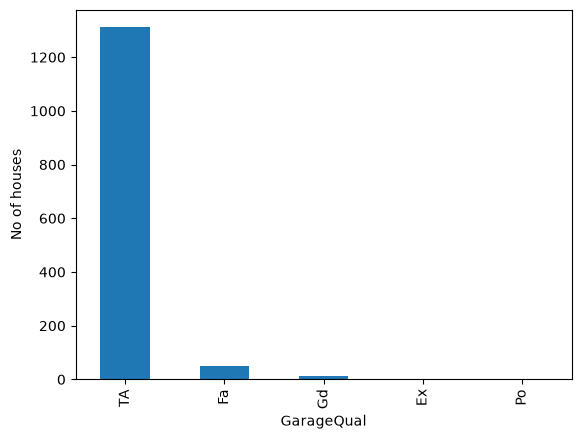

In [6]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot(kind = 'bar')
plt.xlabel("GarageQual")
plt.ylabel("No of houses")

### M1 -- Using Pandas

In [7]:
df['GarageQual'] = df['GarageQual'].fillna('Missing')

Text(0, 0.5, 'No of houses')

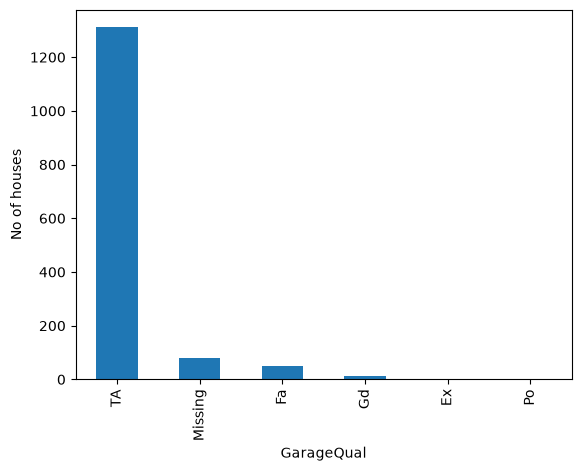

In [8]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot(kind = 'bar')
plt.xlabel("GarageQual")
plt.ylabel("No of houses")

In [16]:
df['GarageQual'].value_counts()

GarageQual
TA         1311
Missing      81
Fa           48
Gd           14
Ex            3
Po            3
Name: count, dtype: int64

### M2 - Using sklearn

In [17]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # stratify = y gives error here - explained in handwritten notes

In [20]:
si = SimpleImputer(strategy='constant', fill_value='Missing')

In [21]:
X_train = si.fit_transform(X_train)
X_test = si.transform(X_test)

In [22]:
si.statistics_ 

array(['Missing', 'Missing'], dtype=object)

In [23]:
# done :)